# Diffusion MNIST


## Import Libraries

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.nn.functional as F

## Define hyper-parameters

In [2]:
IMG_SIZE = 28
BATCH_SIZE = 128
EPOCHS = 4
T = 300
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Downlaod and Create a dataloader

In [3]:
transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x * 2 - 1)
])

In [4]:
dataset = torchvision.datasets.MNIST(root="./data", train=True, transform=transform, download=True)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

## Forward Pass

**Forward Pass**
$$
x_t = \sqrt{\bar{\alpha}_t} \cdot x_0 + \sqrt{1 - \bar{\alpha}_t} \cdot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)
$$


In [5]:
beta_start = 1e-4
beta_end = 0.02
betas = torch.linspace(beta_start, beta_end, T).to(DEVICE)
alphas = 1 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

In [6]:
def forward_diffusion(x0, t, noise=None):
  '''
  alphas_cumprod[t] represent bar_alpha_t
  alphas are 1D but get reshaped to 4D(broadcasted to 4D)
  '''
  if noise is None:
    noise = torch.randn_like(x0)

  sqrt_alpha_cumprod = torch.sqrt(alphas_cumprod[t])[:, None, None, None]
  sqrt_one_minus_alpha_cumprod = torch.sqrt(1 - alphas_cumprod[t])[:, None, None, None]
  return sqrt_alpha_cumprod * x0 + sqrt_one_minus_alpha_cumprod * noise, noise

## Backward pass and Model

Here we input the nosiy image and time step info to the model and make the model to predict the injected noise

In [7]:
def get_timestep_embedding(timesteps, embedding_dim):
  """Create sinusoidal timestep embeddings like in transformers.

  input:
    timesteps: (N,) ex. [t,t,t, .... t]
    embedding_dim: scalr value

  output:
    emd: (N, embedding_dim)
  """

  half_dim = embedding_dim // 2
  device = timesteps.device
  exp_range = torch.exp(-torch.arange(
      half_dim, dtype=torch.float32, device=device) *
      (torch.log(torch.tensor(10000.0, device=device)) / (half_dim - 1)))
  emb = timesteps[:, None].float() * exp_range[None, :]
  emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)
  return emb


class ResidualBlock(nn.Module):
  """Building blocks in the UNet

  inputs:
    x: (noisy) images (N, C_in, H, W)
    t_emb (N, embedding_dim)

  output:
    new_x: (N, C_out, H, W)
  """
  def __init__(self, in_channels, out_channels, time_emb_dim, dropout=0.1):
    super().__init__()
    self.time_mlp = nn.Linear(time_emb_dim, out_channels)
    self.block1 = nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
        nn.GroupNorm(8, out_channels),
        nn.SiLU())

    self.block2 = nn.Sequential(
        nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
        nn.GroupNorm(8, out_channels),
        nn.SiLU())

    self.residual_conv = (
        nn.Conv2d(in_channels, out_channels, kernel_size=1)
        if in_channels != out_channels else nn.Identity())

    self.dropout = nn.Dropout(dropout)

  def forward(self, x, t_emb):
    h = self.block1(x)
    time_emb = self.time_mlp(t_emb).view(t_emb.size(0), -1, 1, 1)
    h = h + time_emb
    h = self.block2(h)
    return self.residual_conv(x) + self.dropout(h)


class UNet(nn.Module):
  '''This model takes nosiy images and time steps and predict the injected noises

  inputs:
    x(noisy images): (N, 1, 28, 28)
    t(time steps) (N, )

  output:
    self.output(xu1)(predicted noise)  (N, 1, 28, 28)
  '''
  def __init__(self, img_channels=1, base_channels=64, time_emb_dim=256):
    super().__init__()
    self.time_mlp = nn.Sequential(
        nn.Linear(time_emb_dim, time_emb_dim),
        nn.SiLU(),
        nn.Linear(time_emb_dim, time_emb_dim)
    )

    # Downsampling path
    self.enc1 = ResidualBlock(img_channels, base_channels, time_emb_dim)
    self.enc2 = ResidualBlock(base_channels, base_channels * 2, time_emb_dim)
    self.enc3 = ResidualBlock(base_channels * 2, base_channels * 4, time_emb_dim)
    self.pool = nn.MaxPool2d(kernel_size=2)

    # Bottleneck
    self.middle = ResidualBlock(base_channels * 4, base_channels * 4, time_emb_dim)

    # Upsampling path
    self.up3 = ResidualBlock(base_channels * 8, base_channels * 2, time_emb_dim)
    self.up2 = ResidualBlock(base_channels * 4, base_channels, time_emb_dim)
    self.up1 = ResidualBlock(base_channels * 2, base_channels, time_emb_dim)

    # Final output layer
    self.output = nn.Conv2d(base_channels, img_channels, kernel_size=1)

  def forward(self, noisy_img, t):
    # generate embeddings
    t_emb = get_timestep_embedding(t, self.time_mlp[0].in_features).to(x.device)
    t_emb = self.time_mlp(t_emb)

    # downsampling
    x1 = self.enc1(noisy_img, t_emb)
    x2 = self.enc2(self.pool(x1), t_emb)
    x3 = self.enc3(self.pool(x2), t_emb)

    # bottleneck
    xm = self.middle(self.pool(x3), t_emb)

    # upsampling
    def upsample_to(x, target_size):
      return F.interpolate(x, size=target_size, mode="nearest")

    xu3 = self.up3(torch.cat([upsample_to(xm, x3.shape[-2:]), x3], dim=1), t_emb)
    xu2 = self.up2(torch.cat([upsample_to(xu3, x2.shape[-2:]), x2], dim=1), t_emb)
    xu1 = self.up1(torch.cat([upsample_to(xu2, x1.shape[-2:]), x1], dim=1), t_emb)

    return self.output(xu1)

In [8]:
model = UNet(img_channels=1, base_channels=64, time_emb_dim=256).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
loss_fn = nn.MSELoss()

## Train

**Pesduo code for training**

1. generate a random time step
2. generate a fake image with it
3. put the time step and original image and create a noisy image
4. put the nosisyimage and time step info to the model and predict the injected noise
5. calcualete the loss with MSE between real noise and predicted noise
6. do the gradient descent




**Loss**


$$
L(\theta) = \mathbb{E}_{x_0, \epsilon, t} \left[ \left\| \epsilon - \epsilon_\theta(x_t, t) \right\|^2 \right]
$$

In [9]:
from tqdm.notebook import tqdm

print("Training...")
for epoch in range(EPOCHS):
  loop = tqdm(loader, desc=f"Epoch [{epoch+1}/{EPOCHS}]", leave=False)

  for x, _ in loop:
    x = x.to(DEVICE)

    ### forwad pass - make noisy image and store true added noise
    t = torch.randint(0, T, (x.shape[0],), device=DEVICE).long()  # shape: (N,)
    noisy_x, noise = forward_diffusion(x, t, noise=None)

    ### bakcward pass - with given time steps and noisy images predict the injected noise
    pred_noise = model(noisy_x, t)

    ### calculate loss using MSE or L2 distance
    loss = loss_fn(pred_noise, noise)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # update progress bar description with current loss
    loop.set_postfix({"loss": loss.item()})

  print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {loss.item():.4f}")

Training...


Epoch [1/4]:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch [1/4] Loss: 0.0929


Epoch [2/4]:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch [2/4] Loss: 0.0705


Epoch [3/4]:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch [3/4] Loss: 0.0517


Epoch [4/4]:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch [4/4] Loss: 0.0436


## Inference

During inference we start with the nosiy image and repeat the following procedurem here epsilion(x_t, t) is the predicted noise via the model.

$$
x_{t-1} = \frac{1}{\sqrt{\alpha_t}} \left( x_t - \frac{\beta_t}{\sqrt{1 - \bar{\alpha}_t}} \cdot \epsilon_\theta(x_t, t) \right) + \sigma_t \cdot z, \quad z \sim \mathcal{N}(0, I)
$$

In [10]:
@torch.no_grad()
def sample(model, n_samples):
  model.eval()
  x = torch.randn((n_samples, 1, IMG_SIZE, IMG_SIZE), device=DEVICE) # n_samples number of noisy images
  for t in reversed(range(T)):
    t_batch = torch.full((n_samples,), t, device=DEVICE, dtype=torch.long) # tensor([t,t,t, .... t]) and the length of tensor is n_samples
    predicted_noise = model(x, t_batch)
    alpha = alphas[t] # alpha_t
    alpha_cumprod = alphas_cumprod[t] # tilda alpha_t
    beta = betas[t] # beta_t

    # add the random noise when time step is 0.
    if t > 0:
      random_noise = torch.randn_like(x)
    else:
      random_noise = torch.zeros_like(x)

    x = (1 / torch.sqrt(alpha)) * (x - (beta / torch.sqrt(1 - alpha_cumprod)) * predicted_noise) + torch.sqrt(beta) * random_noise
    x = torch.clamp(x, -1, 1)

  return (x + 1) / 2

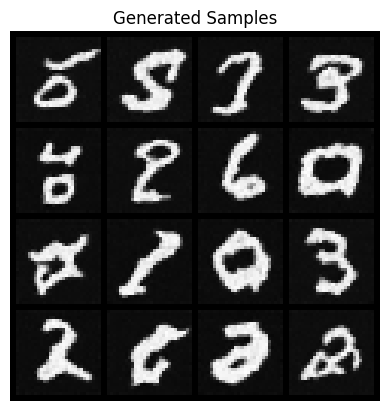

In [11]:
samples = sample(model, n_samples=16)
import matplotlib.pyplot as plt

grid = torchvision.utils.make_grid(samples.cpu(), nrow=4)
plt.imshow(grid.permute(1, 2, 0))
plt.title("Generated Samples")
plt.axis("off")
plt.show()